In [22]:
fs = 44100 ##samples/seconds 1/fs ms between samples
fc = 4000 ##carrier wave frequency in Hz
Ts = 2.2676e-3 ##each symbol is 2.2676 ms long
μ = 0.00022676 ##maximum delay of the channel in seconds (2.2676 ms)
import numpy as np
import matplotlib.pyplot as plt

N = int(round(fs * Ts)) ##number of samples per symbol
mu = int(round(fs * μ)) ##maximum delay of the channel in samples (2.2676 ms)
alpha = 3/18 ##roll-off factor of the pulse shaping filter


p = np.sin(np.pi * np.arange(N) / N) #Bandlimited pulse shaping filter (sinc function)


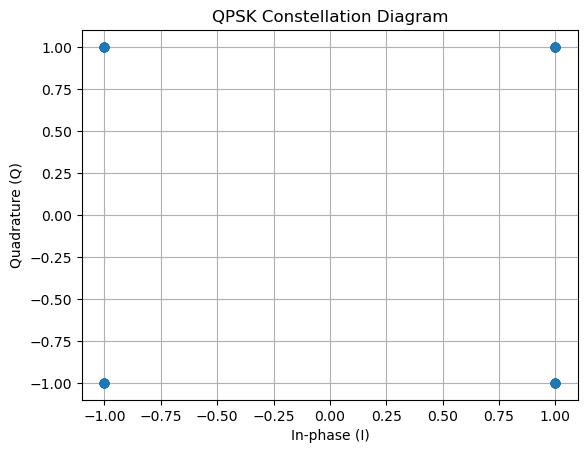

In [23]:
bits = np.random.randint(0, 2, 100000) ##generate random bits to transmit
b = bits.reshape(-1, 2) ##reshape bits into pairs for QPSK modulation
aI = np.where(b[:, 0] == 0,  1.0, -1.0)  ##map the first bit of each pair to the in-phase component (1 for 0, -1 for 1)
aQ = np.where(b[:, 1] == 0,  1.0, -1.0)  ##map the second bit of each pair to the quadrature component
a = aI + 1j * aQ ##combine in-phase and quadrature components
plt.plot(aI[:100], aQ[:100], 'o') ##plot the first 100 symbols in the constellation diagram
plt.xlabel('In-phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('QPSK Constellation Diagram')
plt.grid()
plt.show()  

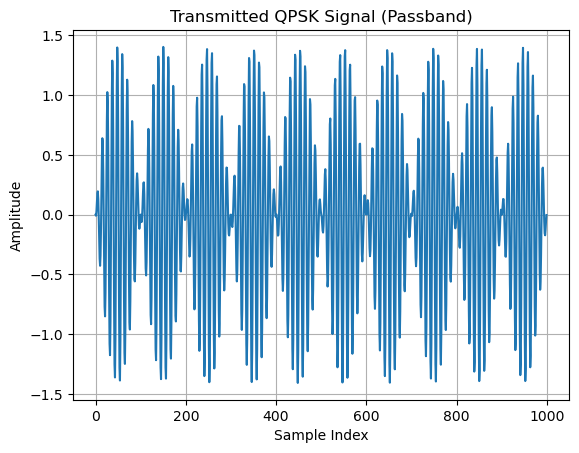

In [24]:
Ns = len(a)
n  = np.arange(Ns * N)

I_bb = np.repeat(aI, N) * np.tile(p, Ns)   # I baseband: pulse-shaped
Q_bb = np.repeat(aQ, N) * np.tile(p, Ns)   # Q baseband: pulse-shaped

cos_c = np.cos(2 * np.pi * fc * n / fs) # carrier wave for upconversion
sin_c = np.sin(2 * np.pi * fc * n / fs) # carrier wave for upconversion

s_passband = I_bb * cos_c - Q_bb * sin_c   # upconvert to passband
plt.plot(s_passband[:1000]) ##plot the first 1000 samples of the transmitted signal
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Transmitted QPSK Signal (Passband)')
plt.grid()
plt.show()

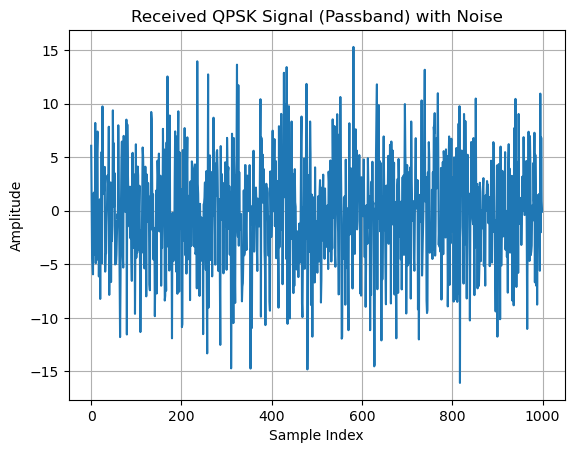

In [25]:
# Channel
s_delayed = np.concatenate([np.zeros(mu), s_passband[:-mu]])
r = np.sqrt(1 - alpha**2) * s_passband + alpha * s_delayed

# Add noise (pick a sigma to test with, e.g. sigma = 1.0)
sigma = 5.0
noise = sigma * np.random.randn(len(r))
r = r + noise
plt.plot(r[:1000]) ##plot the first 1000 samples of the received signal
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received QPSK Signal (Passband) with Noise')
plt.grid()
plt.show()

Number of bit errors: 13183 out of 100000 bits
Bit error rate: 0.131830


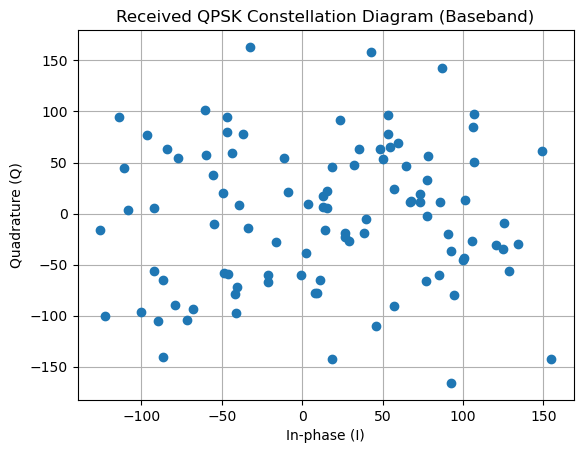

Symbol counts in received constellation diagram:
Symbol (1, 1): 12573 occurrences
Symbol (1, 0): 12486 occurrences
Symbol (0, 1): 12539 occurrences
Symbol (0, 0): 12402 occurrences


In [26]:
r_I = 2* r * cos_c ##downconvert to baseband (I component)
r_Q = -2* r * sin_c ##downconvert to baseband (Q component with sign change)

r_I_mat = r_I.reshape(Ns, N) ##reshape into symbols
r_Q_mat = r_Q.reshape(Ns, N) ##reshape into symbols

y_I = r_I_mat @ p ##matched filter for I component
y_Q = r_Q_mat @ p ##matched filter for Q component

bits_I_hat = (y_I < 0).astype(int)
bits_Q_hat = (y_Q < 0).astype(int)

bits_hat = np.column_stack([bits_I_hat, bits_Q_hat]).flatten()
num_errors = np.sum(bits != bits_hat)
print(f'Number of bit errors: {num_errors} out of {len(bits)} bits')
print(f'Bit error rate: {num_errors / len(bits):.6f}')
plt.plot(y_I[:100], y_Q[:100], 'o') ##plot the first 100 symbols in the received constellation diagram
plt.xlabel('In-phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('Received QPSK Constellation Diagram (Baseband)')
plt.grid()
plt.show()
#print frequency of different symbols in the received constellation diagram
from collections import Counter
symbol_counts = Counter(zip(bits_I_hat, bits_Q_hat))
print("Symbol counts in received constellation diagram:")
for symbol, count in symbol_counts.items():
    print(f"Symbol {symbol}: {count} occurrences") 



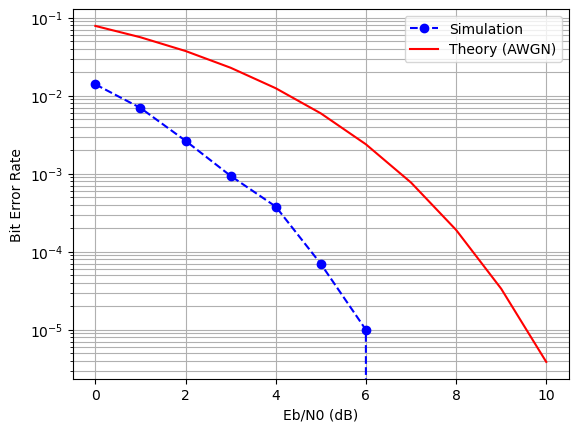

In [27]:
from scipy.special import erfc
EbN0_dB = np.arange(0, 11, 1) ##Eb/N0 range in dB
EbN0 = 10 ** (EbN0_dB / 10) ##convert Eb/N0 from dB to linear scale
Eb_disc = np.sum(s_passband**2) / (2 * len(bits))
BER_sim = np.zeros(len(EbN0))

for i, EbN0_i in enumerate(EbN0):
    sigma     = np.sqrt(Eb_disc / (2 * EbN0_i))
    s_delayed = np.concatenate([np.zeros(mu), s_passband[:-mu]])
    r         = np.sqrt(1 - alpha**2) * s_passband + alpha * s_delayed
    r         = r + sigma * np.random.randn(len(r))

    r_I = 2 * r * cos_c
    r_Q = -2 * r * sin_c
    y_I = r_I.reshape(Ns, N) @ p
    y_Q = r_Q.reshape(Ns, N) @ p
    bits_I_hat = (y_I < 0).astype(int)
    bits_Q_hat = (y_Q < 0).astype(int)
    bits_hat   = np.column_stack([bits_I_hat, bits_Q_hat]).flatten()
    BER_sim[i] = np.sum(bits != bits_hat) / len(bits)

BER_theory = 0.5 * erfc(np.sqrt(EbN0))
plt.semilogy(EbN0_dB, BER_sim,    'bo--', label='Simulation')
plt.semilogy(EbN0_dB, BER_theory, 'r-',   label='Theory (AWGN)')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Bit Error Rate')
plt.grid(True, which='both')
plt.legend()
plt.show()

    
      
    